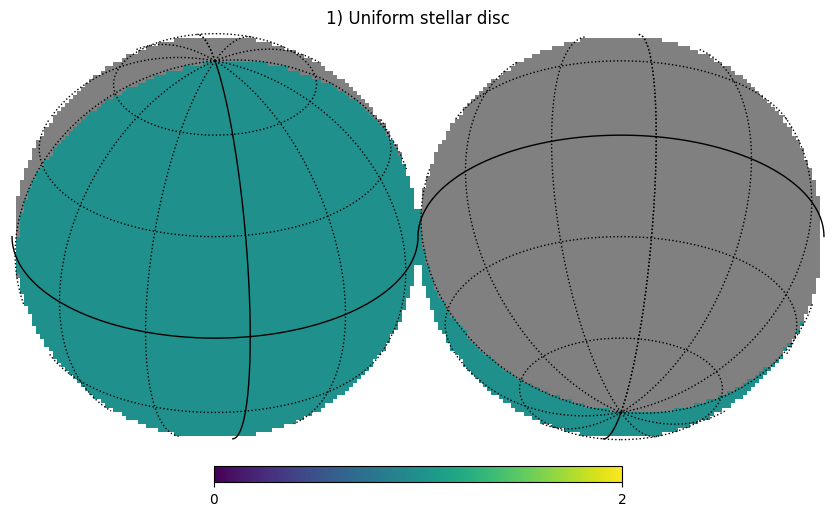

In [13]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

# inline plotting
%matplotlib inline

# 1) MAKE A MAP OF A STAR
# -----------------------
NSIDE = 128
NPIX  = hp.nside2npix(NSIDE)
ipix  = np.arange(NPIX)

# get unit vectors for every pixel
x, y, z = hp.pix2vec(NSIDE, ipix)
theta, phi = hp.pix2ang(NSIDE, ipix)

# define the visible hemisphere (observer along +z)
visible = x > 0

# uniform‐brightness map
star_map = np.full(NPIX, hp.UNSEEN)
star_map[visible] = 1.0

# # plot with a gnomonic projection centered on the sub‐observer point
# hp.gnomview(
#     star_map,
#     rot=[0, 90],           # rotate so that +z is in center
#     title="1) Uniform stellar disc",
#     xsize=200,
# )
# hp.graticule()

hp.orthview(
    star_map,
    rot=[10, 30],           # rotate so that +z is in center
    title="1) Uniform stellar disc",
    xsize=200,
)
hp.graticule()


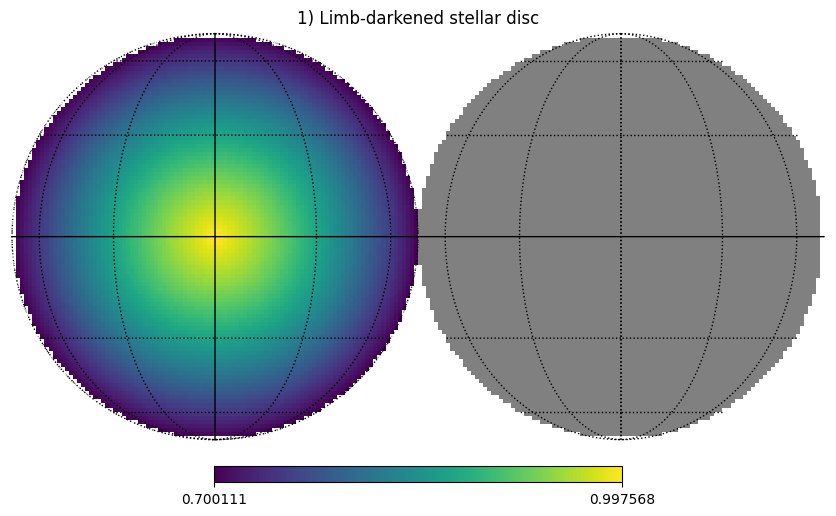

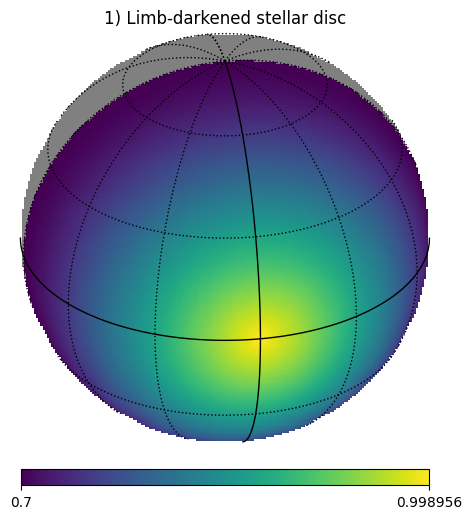

In [20]:
# Adding limb darkening

def quad_limb_dark(mu, u1, u2):
    """
    Compute the quadratic limb-darkening profile.

    Parameters
    ----------
    mu : array_like
        Cosine of the angle from the surface normal (μ = cos θ), between 0 and 1.
    u1, u2 : float
        Quadratic limb-darkening coefficients.

    Returns
    -------
    I_over_I0 : ndarray
        Normalized intensity I(μ)/I(1).
    """
    mu = np.asarray(mu)
    return 1.0 - u1*(1.0 - mu) - u2*(1.0 - mu)**2

# Example usage:
# mu = np.linspace(0, 1, 100)
# profile = quad_limb_dark(mu, u1=0.3, u2=0.2)


for pix in ipix[visible]:
    # mu = y^2 + z^2
    mu = 1-np.sqrt(y[pix]**2 + z[pix]**2)
    if mu > 1 or mu < 0:
        #make a warning
        print(f"Warning: mu value {mu} out of bounds for pixel {pix}.")

    mu = np.clip(mu, 0, 1)  # ensure mu is in [0, 1]

    # limb darkening coefficients
    u1, u2 = 0.2, 0.1

    # compute the intensity profile
    star_map[pix] = quad_limb_dark(mu, u1, u2)


# # plot with a gnomonic projection centered on the sub‐observer point
# hp.gnomview(
#     star_map,
#     rot=[0, 90],           # rotate so that +z is in center
#     title="1) Limb-Darkened stellar disc",
#     xsize=200,
# )
# hp.graticule()

hp.orthview(
    star_map,
    rot=[0, 0],           # rotate so that +z is in center
    title="1) Limb-darkened stellar disc",
    xsize=200,
)
hp.graticule()

hp.orthview(
    star_map,
    rot=[10, 30],           # rotate so that +z is in center
    title="1) Limb-darkened stellar disc",
    xsize=200,
    half_sky=True,  # show the whole sky
)
hp.graticule()


In [45]:
#Transit parameters
b=0.2
rp=0.15
n=1000
#
#  Manually calculating the transit chord
z_tr=np.ones(n) * b  # z values for the transit chord at impact parameter b
y_max_tr=np.sqrt(1-z_tr[0]**2)  # y_max for the transit chord

y_tr= np.linspace(-y_max_tr, y_max_tr, n)  # y values for the transit chord
x_tr = np.sqrt(1 - y_tr**2 - z_tr**2)  # x values for the transit chord
vec_tr=np.array([x_tr, y_tr, z_tr]).T  # vectors for the transit chord

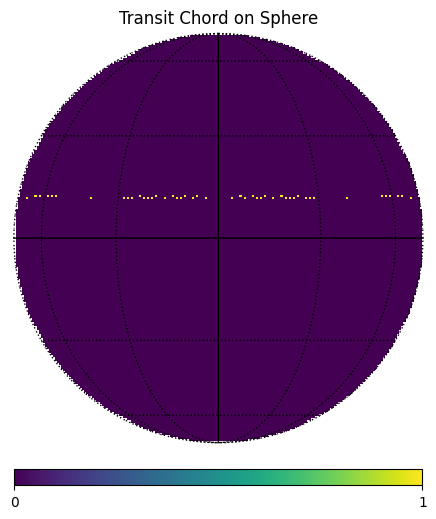

In [ ]:
transit_map = np.full(NPIX, 0)  # initialize the transit map
for element in vec_tr:
    # Convert the vector to pixel index
    pix = hp.vec2pix(NSIDE, element[0], element[1], element[2])
    if pix >= 0 and pix < NPIX:  # Check if the pixel index is valid
        transit_map[pix] = 1  # Set the pixel value to the square of the radius

# 4) Display
hp.orthview(transit_map, title="Transit Chord on Sphere",half_sky=True, xsize=200)
hp.graticule()
plt.show()


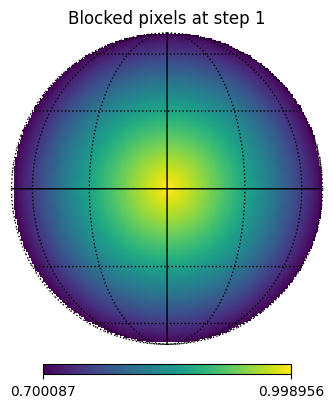

Removing them
Removing them
Removing them
Removing them
Removing them


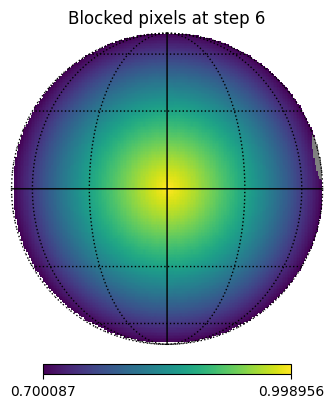

Removing them


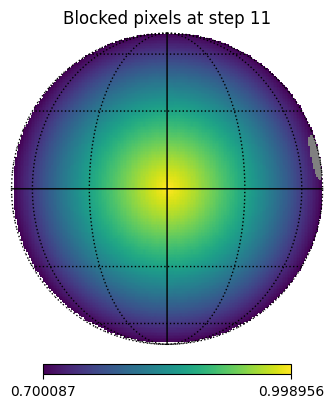

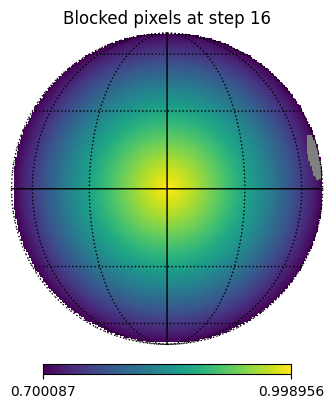

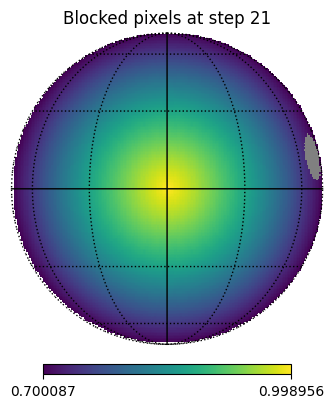

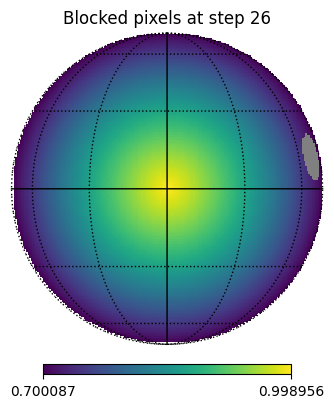

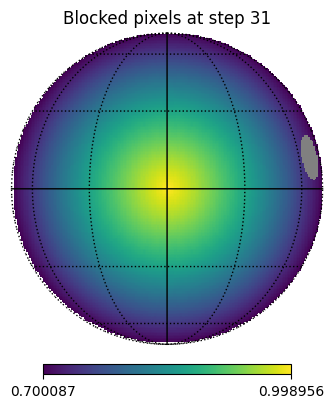

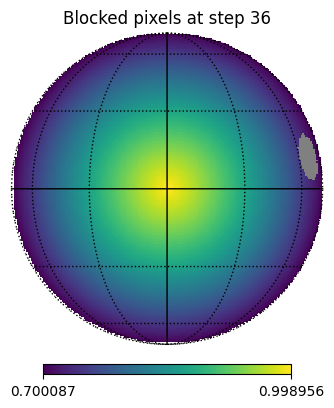

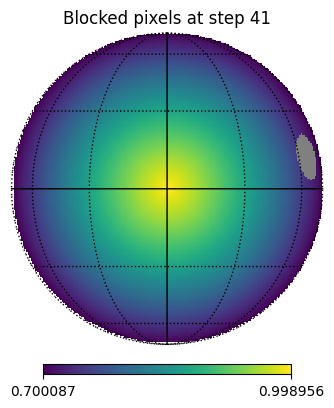

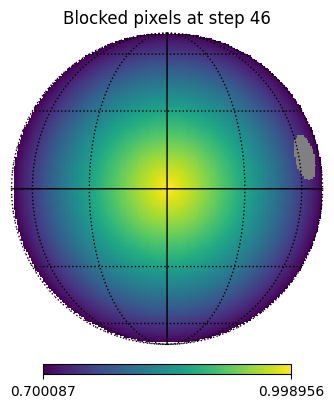

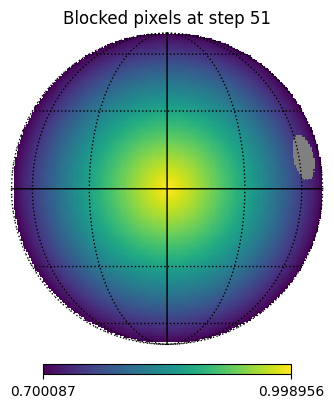

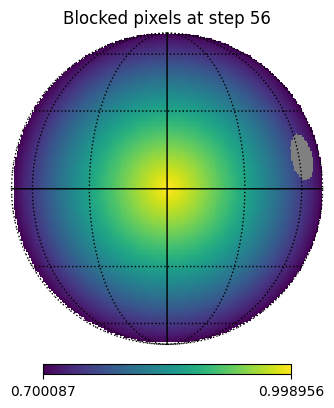

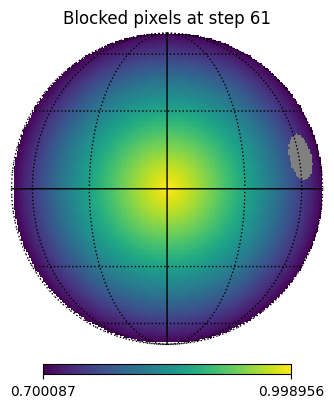

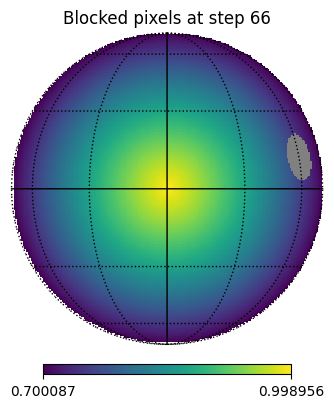

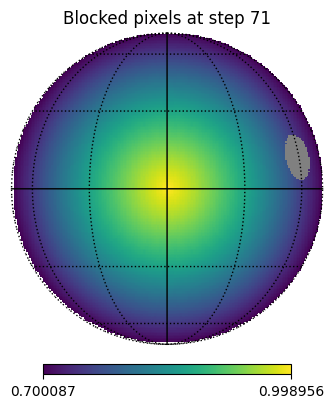

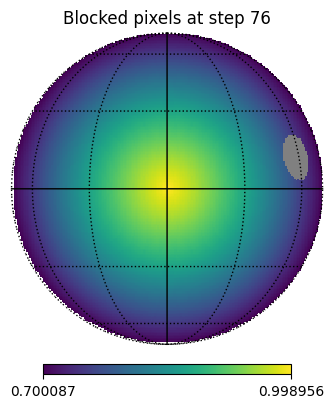

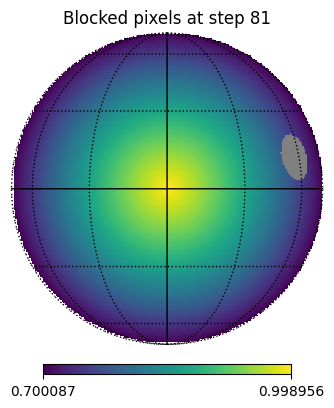

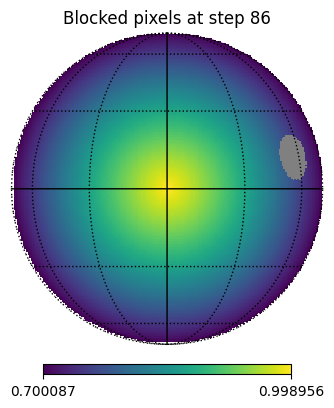

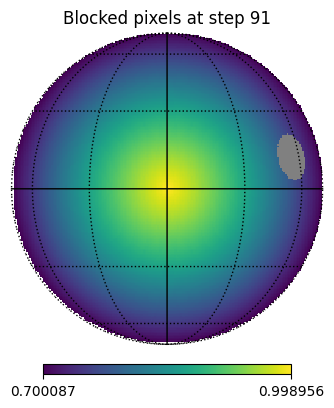

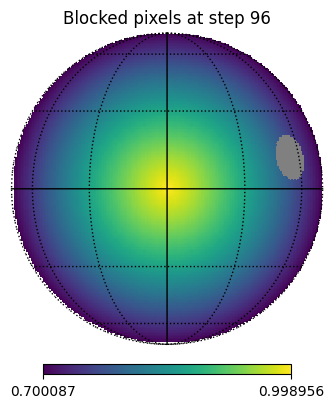

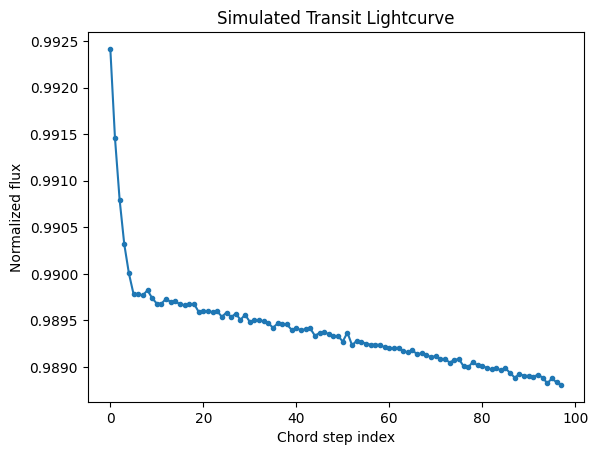

In [66]:
#Making a transit lightcurve
# total out-of-transit flux
F0 = star_map[visible].sum()

vec_tr=np.array([x_tr, y_tr, z_tr]).T  # vectors for the transit chord

# convert planet radius to angular (radians on unit sphere)
# small-angle approx: planet angular radius ≈ rp
ang_rp = rp

# 3) Loop to compute the lightcurve
flux = []
i=0
F_block_list=[]
for vec in vec_tr[:100]:
    i+=1
    # pixels blocked by planet
    ipix_block = hp.query_disc(NSIDE, vec, radius=ang_rp)
    # ipix_block_in=ipix_bloc÷k[np.isin(ipix_block, ipix[visible])]  # only keep visible pixels

    blocked_map = star_map.copy()  # start with the star map
    blocked_map[ipix_block] = hp.UNSEEN  # mark blocked pixels as UNSEEN


    #plot every 10 steps
    if (i-1) % 5 == 0:
        hp.orthview(
            blocked_map,
            title=f"Blocked pixels at step {i}",
            half_sky=True,
            xsize=200,
            hold=True,  # keep the previous plot
        )
        hp.graticule()
        plt.show()

    vals=star_map[ipix_block]
    if (vals < 0).any():
        print(f"Warning: Negative flux in blocked pixels at step {i}.")
        print(F"Removing them")
        F_block= star_map[ipix_block][star_map[ipix_block] > 0].sum()
    else:
        # blocked flux = sum of those pixels
        F_block = star_map[ipix_block].sum()

    F_block_list.append(F_block)
    # residual flux
    flux.append((F0 - F_block) / F0)

flux = np.array(flux)

# 4) Plot the normalized lightcurve
plt.plot(flux[1:-1], '-o', ms=3)
plt.xlabel('Chord step index')
plt.ylabel('Normalized flux')
plt.title('Simulated Transit Lightcurve')
# plt.ylim(1 - (rp*rp*np.pi)/(4*np.pi) * 1.1, 1.01)  # rough y-scale
plt.show()


Spot vector: [ 0.89825437 -0.39132989  0.2       ]


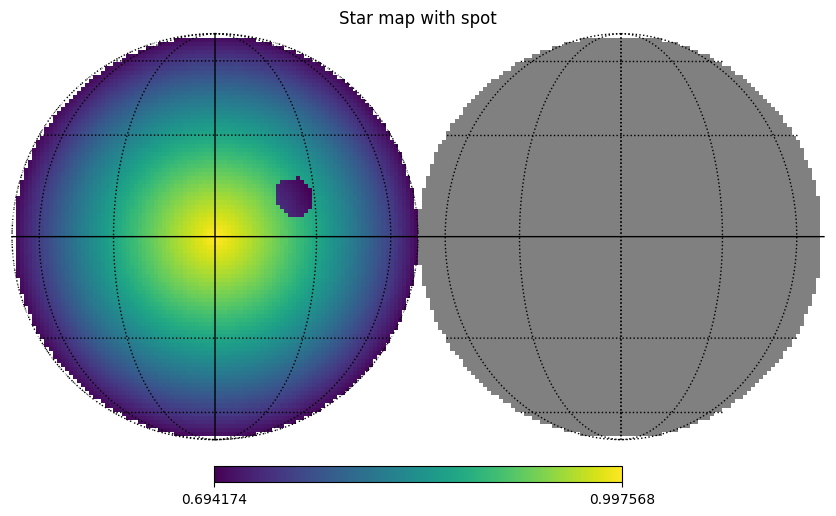

In [ ]:
contrast=0.2
spot_radius = 0.1  # angular radius of the spot in radians

vec_spot=vec_tr[300]
print(f"Spot vector: {vec_spot}")

ipix_spot = hp.query_disc(NSIDE, vec_spot, radius=spot_radius)

star_map_spot = star_map.copy()  # start with the star map
star_map_spot[ipix_spot] = star_map_spot[ipix_spot]*(1-contrast)

hp.orthview(
    star_map_spot,
    title="Star map with spot",
    xsize=200,
)
hp.graticule()

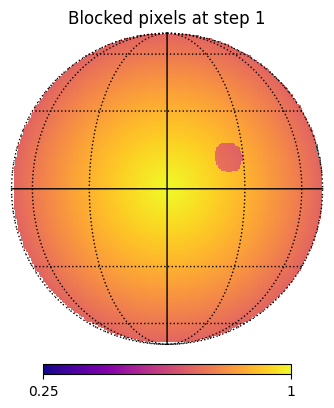

Removing them
Removing them
Removing them
Removing them
Removing them
Removing them


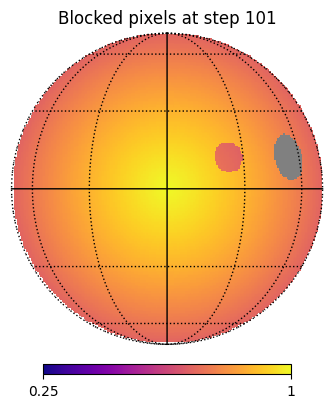

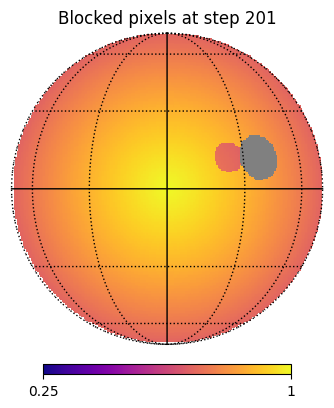

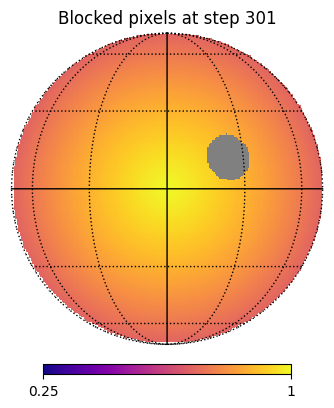

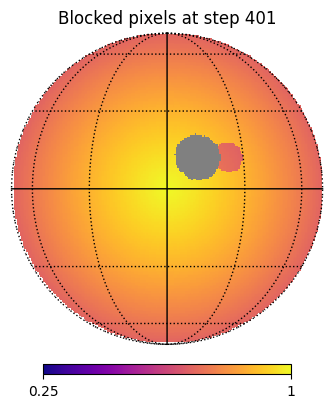

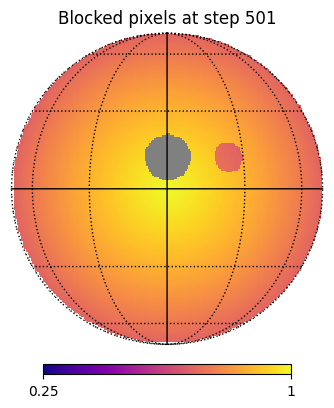

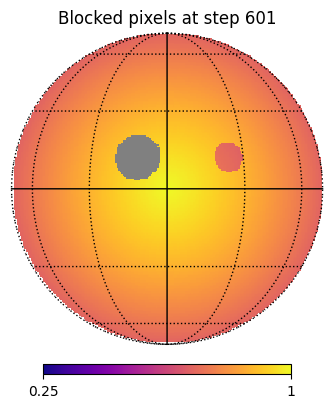

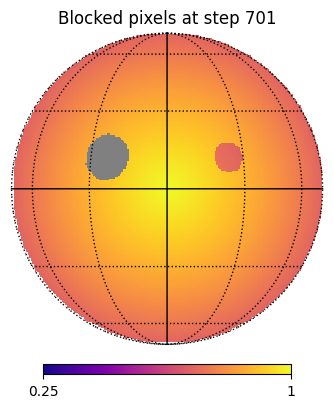

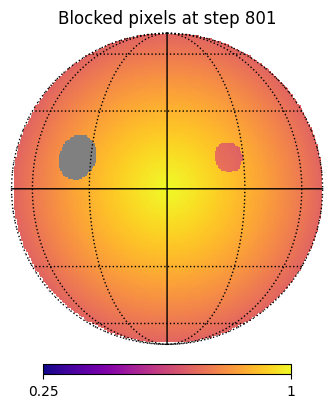

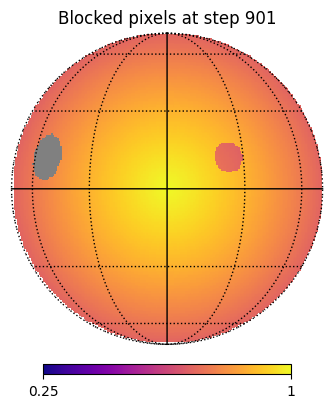

Removing them
Removing them
Removing them
Removing them
Removing them
Removing them


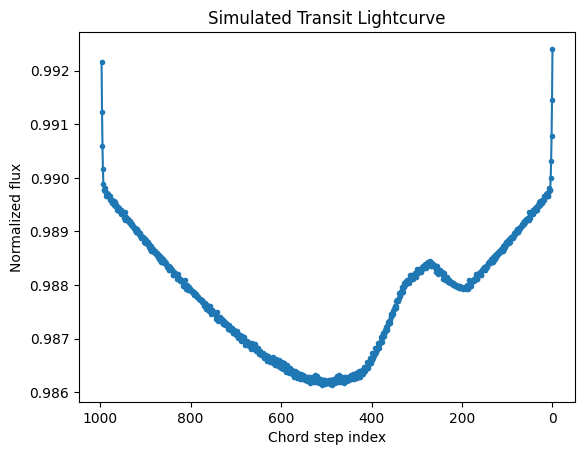

In [ ]:
#Making a transit lightcurve
# total out-of-transit flux
F0 = star_map_spot[visible].sum()

vec_tr=np.array([x_tr, y_tr, z_tr]).T  # vectors for the transit chord

# convert planet radius to angular (radians on unit sphere)
# small-angle approx: planet angular radius ≈ rp
ang_rp = rp

# 3) Loop to compute the lightcurve
flux = []
i=0
F_block_list=[]
for vec in vec_tr:
    i+=1
    # pixels blocked by planet
    ipix_block = hp.query_disc(NSIDE, vec, radius=ang_rp)
    # ipix_block_in=ipix_bloc÷k[np.isin(ipix_block, ipix[visible])]  # only keep visible pixels

    blocked_map = star_map_spot.copy()  # start with the star map
    blocked_map[ipix_block] = hp.UNSEEN  # mark blocked pixels as UNSEEN


    #plot every 10 steps
    if (i-1) % (n/10) == 0:
        hp.orthview(
            blocked_map,
            title=f"Blocked pixels at step {i}",
            half_sky=True,
            xsize=200,
            hold=True,  # keep the previous plot
            cmap='plasma',
            min=0.25, max=1  # set color limits for better visibility
        )
        hp.graticule()

        plt.show()

    vals=star_map_spot[ipix_block]
    if (vals < 0).any():
        print(f"Warning: Negative flux in blocked pixels at step {i}.")
        print(F"Removing them")
        F_block= star_map_spot[ipix_block][star_map_spot[ipix_block] > 0].sum()
    else:
        # blocked flux = sum of those pixels
        F_block = star_map_spot[ipix_block].sum()

    F_block_list.append(F_block)
    # residual flux
    flux.append((F0 - F_block) / F0)

flux = np.array(flux)

# 4) Plot the normalized lightcurve
plt.plot(flux[1:-1], '-o', ms=3)
plt.xlabel('Chord step index')
plt.ylabel('Normalized flux')
plt.title('Simulated Transit Lightcurve')
# plt.ylim(1 - (rp*rp*np.pi)/(4*np.pi) * 1.1, 1.01)  # rough y-scale
plt.gca().invert_xaxis()   # ← here!
plt.show()


In [69]:
#Save the star map with the spot
hp.write_map("star_map_with_spot.fits", star_map_spot, overwrite=True)

setting the output map dtype to [dtype('float64')]


---